##### 06. Multi-step Forecasting: Recursive GRU vs Direct GRU

Notebook này so sánh trực tiếp 2 chiến lược mở rộng model GRU horizon=1 (đã train ở 04_modeling.ipynb)
sang dự báo `HORIZON=6` giờ tới:

- **Recursive GRU**: tái sử dụng nguyên model horizon=1 của 04 (không train lại), gọi lặp lại 6 lần — mỗi
  bước lấy PM2.5 vừa dự đoán làm input cho bước kế tiếp. Đặc trưng ngoại sinh (PM10, CO, NO2, SO2, O3, AOD)
  dùng persistence (giữ nguyên giá trị thật cuối cùng); đặc trưng lịch (hour_sin/cos, month_sin/cos) tính
  chính xác cho từng giờ tương lai.
- **Direct GRU (Vector output)**: model **riêng biệt**, đã được Grid Search và huấn luyện trong phiên bản
  06 trước (`data/processed/gru_multistep_model.pt`) — đổi lớp Linear cuối thành `Linear(hidden, 6)`, ra
  thẳng cả 6 giá trị tương lai trong 1 lần forward pass, không đệ quy.

Cả 2 model đều được **tái sử dụng từ checkpoint đã lưu**, không train lại — notebook này tập trung vào
việc so sánh, không lặp lại quá trình huấn luyện.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn

pd.set_option('display.max_columns', None)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

HORIZON = 6
print(f"HORIZON = {HORIZON} gio")

Device: cpu
HORIZON = 6 gio


##### Load dữ liệu đã xử lý (từ 03_preprocessing.ipynb)

In [2]:
train_scaled = pd.read_csv('data/processed/train_scaled.csv', index_col='time', parse_dates=True)
val_scaled = pd.read_csv('data/processed/val_scaled.csv', index_col='time', parse_dates=True)
test_scaled = pd.read_csv('data/processed/test_scaled.csv', index_col='time', parse_dates=True)
scaler = joblib.load('data/processed/scaler.joblib')

feature_cols = train_scaled.columns.tolist()
pm25_col_idx = feature_cols.index('PM2.5')
n_features = len(feature_cols)

print(f"Train: {len(train_scaled)} dong | Val: {len(val_scaled)} dong | Test: {len(test_scaled)} dong")
print(f"Feature columns ({n_features}): {feature_cols}")


def mae_rmse(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse


def inverse_transform_col(scaled_values, col_idx, scaler, n_features):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, col_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, col_idx]


test_pm25_series = pd.Series(
    inverse_transform_col(test_scaled['PM2.5'].values, pm25_col_idx, scaler, n_features),
    index=test_scaled.index,
)

Train: 24405 dong | Val: 5230 dong | Test: 5230 dong
Feature columns (11): ['PM10', 'PM2.5', 'Carbon Monoxide', 'Nitrogen Dioxide', 'Sulphur Dioxide', 'Ozone', 'Aerosol Optical Depth', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


## PHẦN A — Recursive GRU

Tái sử dụng model horizon=1 đã train ở 04_modeling.ipynb, gọi lặp lại `HORIZON` lần. Toàn bộ được vector
hóa theo batch (6 forward pass phủ hết mọi origin của tập Test) để chạy nhanh.

In [3]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


checkpoint04 = torch.load('data/processed/gru_model.pt', map_location=device, weights_only=False)
horizon1_model = GRUModel(input_size=n_features, hidden_size=checkpoint04['hidden_size'],
                           num_layers=checkpoint04['num_layers'], dropout=checkpoint04['dropout']).to(device)
horizon1_model.load_state_dict(checkpoint04['model_state_dict'])
horizon1_model.eval()
BEST_WINDOW_04 = checkpoint04['window_size']
print(f"Da load model horizon=1 tu 04 (window={BEST_WINDOW_04}h, hidden={checkpoint04['hidden_size']})")


def scale_calendar_value(raw_value, col_name, feature_cols, scaler):
    idx = feature_cols.index(col_name)
    data_min = scaler.data_min_[idx]
    data_max = scaler.data_max_[idx]
    return (raw_value - data_min) / (data_max - data_min)


def recursive_multistep_forecast(model, test_scaled, window_size, horizon, pm25_col_idx, feature_cols, scaler, device):
    data = test_scaled.values.astype(np.float32)
    times = test_scaled.index
    n = len(data)
    n_origins = n - window_size - horizon + 1
    windows = np.stack([data[i:i + window_size] for i in range(n_origins)], axis=0)
    last_real_times = times[window_size - 1: window_size - 1 + n_origins]

    hour_sin_i = feature_cols.index('hour_sin')
    hour_cos_i = feature_cols.index('hour_cos')
    month_sin_i = feature_cols.index('month_sin')
    month_cos_i = feature_cols.index('month_cos')

    preds_scaled = np.zeros((n_origins, horizon), dtype=np.float32)
    model.eval()
    with torch.no_grad():
        for step in range(horizon):
            xb = torch.from_numpy(windows).to(device)
            pred = model(xb).cpu().numpy()
            preds_scaled[:, step] = pred

            future_times = last_real_times + pd.Timedelta(hours=step + 1)
            next_rows = windows[:, -1, :].copy()
            next_rows[:, pm25_col_idx] = pred

            fh = np.array([t.hour for t in future_times])
            fm = np.array([t.month for t in future_times])
            next_rows[:, hour_sin_i] = scale_calendar_value(np.sin(2 * np.pi * fh / 24), 'hour_sin', feature_cols, scaler)
            next_rows[:, hour_cos_i] = scale_calendar_value(np.cos(2 * np.pi * fh / 24), 'hour_cos', feature_cols, scaler)
            next_rows[:, month_sin_i] = scale_calendar_value(np.sin(2 * np.pi * fm / 12), 'month_sin', feature_cols, scaler)
            next_rows[:, month_cos_i] = scale_calendar_value(np.cos(2 * np.pi * fm / 12), 'month_cos', feature_cols, scaler)

            windows = np.concatenate([windows[:, 1:, :], next_rows[:, np.newaxis, :]], axis=1)

    target_times_per_origin = [times[window_size + i: window_size + i + horizon] for i in range(n_origins)]
    return preds_scaled, target_times_per_origin, n_origins


preds_rec_scaled, target_times_rec, n_origins_rec = recursive_multistep_forecast(
    horizon1_model, test_scaled, BEST_WINDOW_04, HORIZON, pm25_col_idx, feature_cols, scaler, device,
)
print(f"Recursive: {n_origins_rec} origin danh gia duoc")

Da load model horizon=1 tu 04 (window=24h, hidden=64)
Recursive: 5201 origin danh gia duoc


## PHẦN B — Direct GRU (Vector Output)

Tái sử dụng model đã được Grid Search và huấn luyện riêng cho bài toán multi-step (window=24h, hidden=32,
lr=0.001 — kết quả Grid Search từ phiên bản trước của notebook này).

In [4]:
class MultiStepGRU(nn.Module):
    def __init__(self, input_size, horizon, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


checkpoint_direct = torch.load('data/processed/gru_multistep_model.pt', map_location=device, weights_only=False)
direct_model = MultiStepGRU(input_size=n_features, horizon=checkpoint_direct['horizon'],
                             hidden_size=checkpoint_direct['hidden_size'], num_layers=checkpoint_direct['num_layers'],
                             dropout=checkpoint_direct['dropout']).to(device)
direct_model.load_state_dict(checkpoint_direct['model_state_dict'])
direct_model.eval()
BEST_WINDOW_DIRECT = checkpoint_direct['window_size']
print(f"Da load model Direct GRU (window={BEST_WINDOW_DIRECT}h, hidden={checkpoint_direct['hidden_size']})")

X_test_direct = np.array(
    [test_scaled.values[i:i + BEST_WINDOW_DIRECT] for i in range(len(test_scaled) - BEST_WINDOW_DIRECT - HORIZON + 1)],
    dtype=np.float32,
)
with torch.no_grad():
    preds_direct_scaled = direct_model(torch.from_numpy(X_test_direct).to(device)).cpu().numpy()
target_times_direct = [test_scaled.index[BEST_WINDOW_DIRECT + i: BEST_WINDOW_DIRECT + i + HORIZON] for i in range(len(preds_direct_scaled))]
print(f"Direct: {len(preds_direct_scaled)} origin danh gia duoc")

Da load model Direct GRU (window=24h, hidden=32)
Direct: 5201 origin danh gia duoc


## PHẦN C — So sánh Recursive GRU vs Direct GRU

Vì 2 model dùng `window_size` khác nhau (nếu có), bảng so sánh chỉ tính trên tập mốc thời gian chung
(`common_start = max(window Recursive, window Direct)`).

In [5]:
common_start = max(BEST_WINDOW_04, BEST_WINDOW_DIRECT)
n_common = min(len(test_scaled) - common_start - HORIZON + 1, n_origins_rec, len(preds_direct_scaled))
offset_rec = common_start - BEST_WINDOW_04
offset_direct = common_start - BEST_WINDOW_DIRECT

mae_rec, rmse_rec = [], []
mae_direct, rmse_direct = [], []

for h in range(HORIZON):
    times_h = pd.DatetimeIndex([target_times_direct[offset_direct + k][h] for k in range(n_common)])
    true_h = test_pm25_series.loc[times_h].values

    pred_rec_h = inverse_transform_col(
        np.array([preds_rec_scaled[offset_rec + k, h] for k in range(n_common)]), pm25_col_idx, scaler, n_features)
    pred_direct_h = inverse_transform_col(
        np.array([preds_direct_scaled[offset_direct + k, h] for k in range(n_common)]), pm25_col_idx, scaler, n_features)

    m, r = mae_rmse(true_h, pred_rec_h); mae_rec.append(m); rmse_rec.append(r)
    m, r = mae_rmse(true_h, pred_direct_h); mae_direct.append(m); rmse_direct.append(r)

print(f"So sanh tren {n_common} moc goc chung (common_start={common_start}h)")
comparison_by_horizon = pd.DataFrame({
    'horizon (h)': range(1, HORIZON + 1),
    'Recursive MAE': mae_rec, 'Direct MAE': mae_direct,
    'Recursive RMSE': rmse_rec, 'Direct RMSE': rmse_direct,
    'Direct thang Recursive (%)': [(1 - d / r) * 100 for r, d in zip(mae_rec, mae_direct)],
})
comparison_by_horizon

So sanh tren 5201 moc goc chung (common_start=24h)


   horizon (h)  Recursive MAE  Direct MAE  Recursive RMSE  Direct RMSE  \
0            1       1.171620    1.209654        2.173576     2.181624   
1            2       2.140201    1.951073        3.483056     3.198205   
2            3       2.987538    2.576469        4.613485     3.972073   
3            4       3.714598    3.028727        5.575627     4.510964   
4            5       4.340971    3.400580        6.383197     4.956078   
5            6       4.879718    3.683256        7.074912     5.274497   

   Direct thang Recursive (%)  
0                   -3.246268  
1                    8.836927  
2                   13.759473  
3                   18.464208  
4                   21.663161  
5                   24.519079  

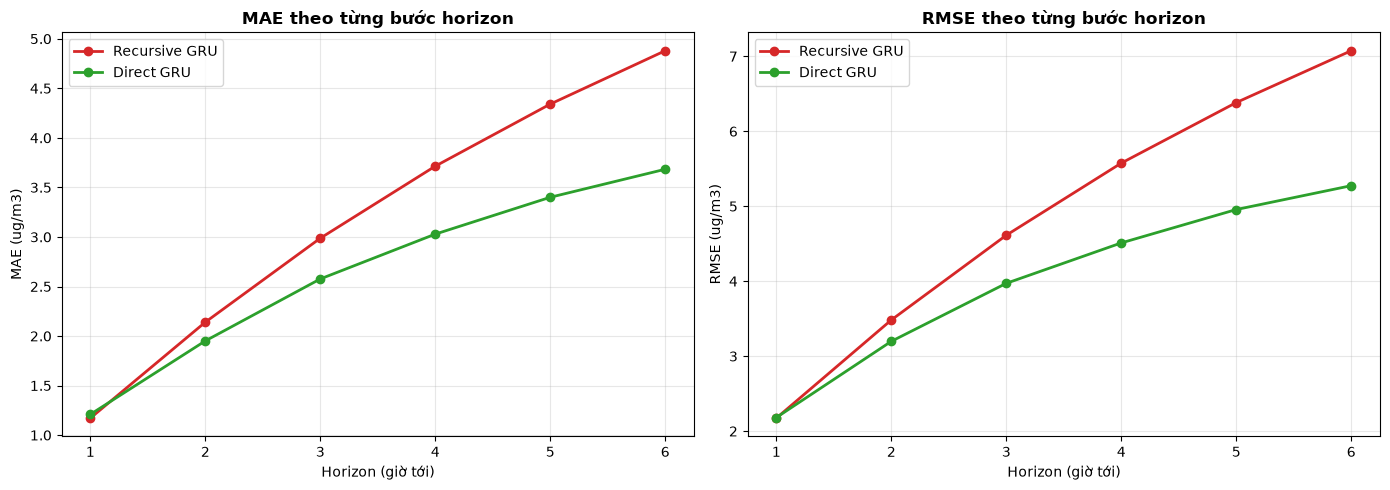

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
h_range = range(1, HORIZON + 1)
axes[0].plot(h_range, mae_rec, marker='o', label='Recursive GRU', color='#d62728', linewidth=2)
axes[0].plot(h_range, mae_direct, marker='o', label='Direct GRU', color='#2ca02c', linewidth=2)
axes[0].set_xlabel('Horizon (giờ tới)'); axes[0].set_ylabel('MAE (ug/m3)')
axes[0].set_title('MAE theo từng bước horizon', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(h_range, rmse_rec, marker='o', label='Recursive GRU', color='#d62728', linewidth=2)
axes[1].plot(h_range, rmse_direct, marker='o', label='Direct GRU', color='#2ca02c', linewidth=2)
axes[1].set_xlabel('Horizon (giờ tới)'); axes[1].set_ylabel('RMSE (ug/m3)')
axes[1].set_title('RMSE theo từng bước horizon', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

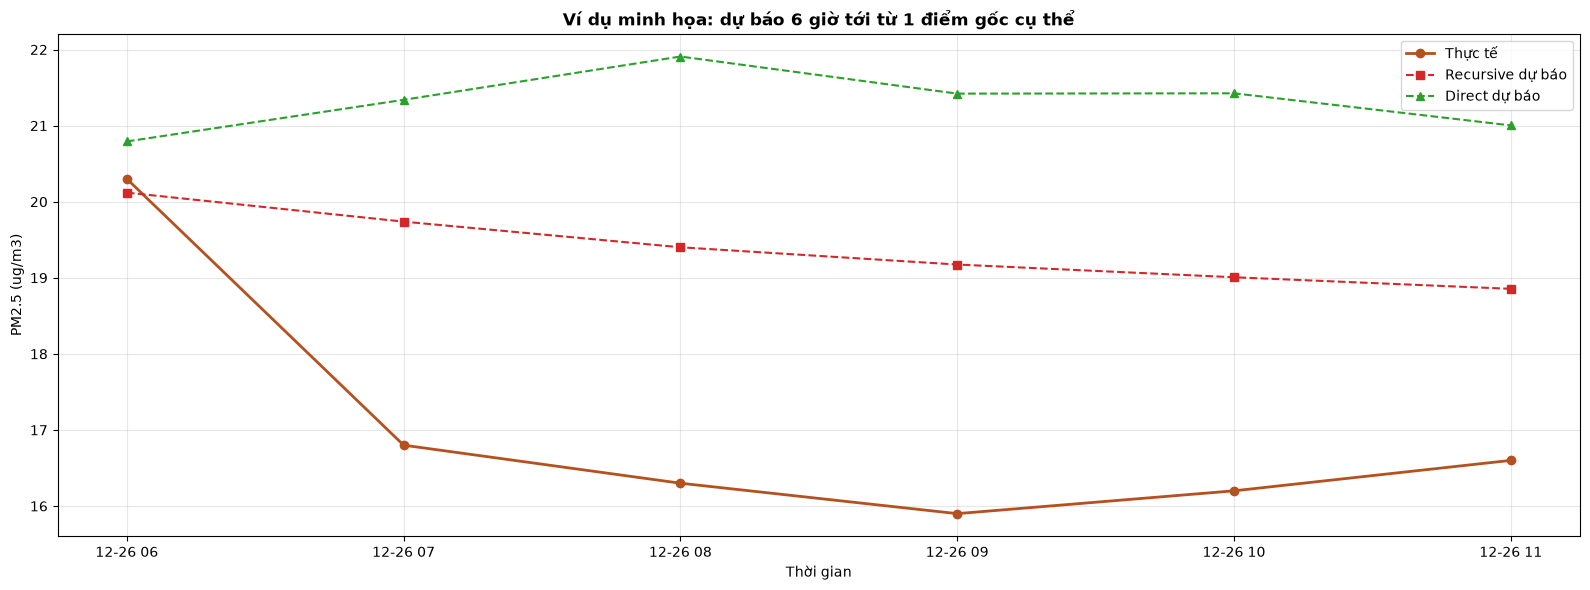

In [7]:
plt.figure(figsize=(16, 6))
sample_origin = 100
times_ex = target_times_direct[offset_direct + sample_origin]
true_ex = test_pm25_series.loc[times_ex].values
pred_rec_ex = inverse_transform_col(preds_rec_scaled[offset_rec + sample_origin], pm25_col_idx, scaler, n_features)
pred_direct_ex = inverse_transform_col(preds_direct_scaled[offset_direct + sample_origin], pm25_col_idx, scaler, n_features)

plt.plot(times_ex, true_ex, marker='o', label='Thực tế', color='#b4511f', linewidth=2)
plt.plot(times_ex, pred_rec_ex, marker='s', label='Recursive dự báo', color='#d62728', linestyle='--')
plt.plot(times_ex, pred_direct_ex, marker='^', label='Direct dự báo', color='#2ca02c', linestyle='--')
plt.xlabel('Thời gian'); plt.ylabel('PM2.5 (ug/m3)')
plt.title(f'Ví dụ minh họa: dự báo {HORIZON} giờ tới từ 1 điểm gốc cụ thể', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Phân tích Residual

[h=1] Recursive: mean=0.175, std=2.167  |  Direct: mean=-0.042, std=2.181
[h=6] Recursive: mean=0.644, std=7.046  |  Direct: mean=0.316, std=5.265


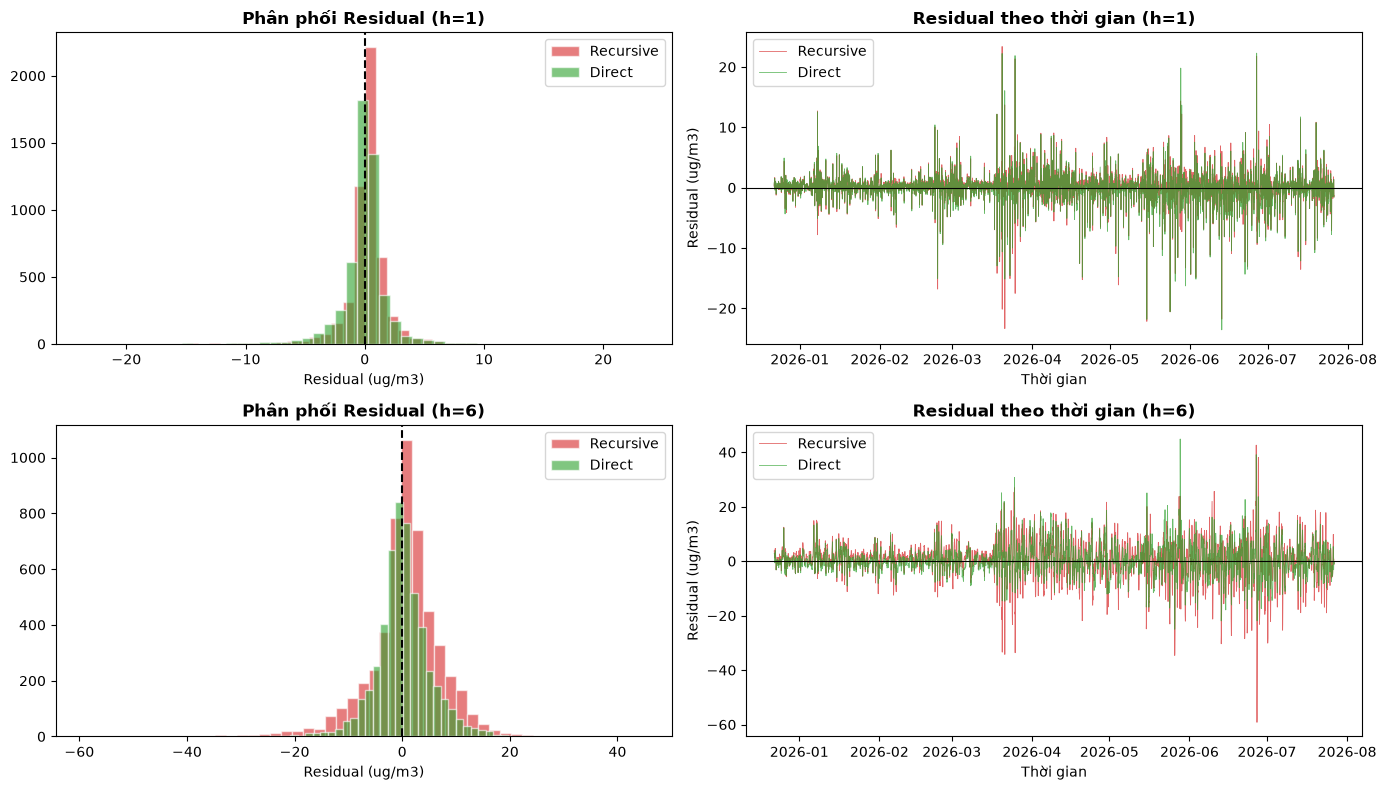

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row, (h_show, label) in enumerate([(1, 'h=1'), (HORIZON, f'h={HORIZON}')]):
    times_h = pd.DatetimeIndex([target_times_direct[offset_direct + k][h_show - 1] for k in range(n_common)])
    true_h = test_pm25_series.loc[times_h].values
    res_rec = true_h - inverse_transform_col(
        np.array([preds_rec_scaled[offset_rec + k, h_show - 1] for k in range(n_common)]), pm25_col_idx, scaler, n_features)
    res_direct = true_h - inverse_transform_col(
        np.array([preds_direct_scaled[offset_direct + k, h_show - 1] for k in range(n_common)]), pm25_col_idx, scaler, n_features)

    axes[row, 0].hist(res_rec, bins=50, color='#d62728', alpha=0.6, label='Recursive', edgecolor='white')
    axes[row, 0].hist(res_direct, bins=50, color='#2ca02c', alpha=0.6, label='Direct', edgecolor='white')
    axes[row, 0].axvline(0, color='black', linestyle='--')
    axes[row, 0].set_title(f'Phân phối Residual ({label})', fontweight='bold')
    axes[row, 0].set_xlabel('Residual (ug/m3)')
    axes[row, 0].legend()

    axes[row, 1].plot(times_h, res_rec, linewidth=0.6, color='#d62728', alpha=0.7, label='Recursive')
    axes[row, 1].plot(times_h, res_direct, linewidth=0.6, color='#2ca02c', alpha=0.7, label='Direct')
    axes[row, 1].axhline(0, color='black', linewidth=0.8)
    axes[row, 1].set_title(f'Residual theo thời gian ({label})', fontweight='bold')
    axes[row, 1].set_xlabel('Thời gian'); axes[row, 1].set_ylabel('Residual (ug/m3)')
    axes[row, 1].legend()

    print(f"[{label}] Recursive: mean={res_rec.mean():.3f}, std={res_rec.std():.3f}  |  "
          f"Direct: mean={res_direct.mean():.3f}, std={res_direct.std():.3f}")

plt.tight_layout()
plt.show()

##### Kết luận

Điền nhận xét dựa trên bảng/biểu đồ so sánh ở trên: Direct GRU vượt trội Recursive GRU ở những horizon
nào, mức chênh lệch bao nhiêu %? Độ phân tán residual (std) của 2 model khác nhau ra sao theo horizon —
Recursive có tăng nhanh hơn Direct như kỳ vọng từ hiện tượng dồn sai số (error compounding) không?